# Table Web-Scraping Colloborative Group Project
## Christopher Smith-Thomas and khawaja bilal Sultan

This web-scraping code is collecting data from a table about Soccer in the US, specifically the average attendance per league season and the club with the highest average attendance. The table is sourced from Wikipedia.

* This code is to import libraries that will alow further code to parse HTML, open URLS, display the table, etc.

In [4]:
# CSC221 Web Scraper
# Scrapes the Wikipedia table:
# "Attendances: The average attendance per league season and the club with the highest average attendance"

# Avoid SSL issues
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Imports
import requests
from bs4 import BeautifulSoup
import pandas as pd
from IPython.display import display
from io import StringIO



* This code first downloads the page HTML and then reads all the tables
* Then it filters to find the right table

In [5]:
# URL
url = "https://en.wikipedia.org/wiki/Soccer_in_the_United_States"

# Add browser header to bypass 403 error
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Download page HTML first
response = requests.get(url, headers=headers)

# Read tables from downloaded HTML instead of direct URL
tables = pd.read_html(StringIO(response.text))

# Find attendance table
target_df = None

for df in tables:
    
    cols = [str(col).strip() for col in df.columns]

    if ("Season" in cols and
        "League average" in cols and
        "Best club" in cols and
        "Best club average" in cols):
        
        target_df = df
        break

* This final bit of code is to write to a CSV file all the data from the table
* If successful, the code will print ""Data saved to CSC221-webscrape-data.csv"" and create the file in the current directory
* The code will then displa

In [6]:
# If found
if target_df is not None:

    # Save CSV file
    target_df.to_csv("CSC221-webscrape-data.csv", index=False)

    print("Data saved to CSC221-webscrape-data.csv")

    # Display table nicely
    display(target_df)

else:
    print("Attendance table not found.")

Data saved to CSC221-webscrape-data.csv


,Season,League average,Best club,Best club average
0,2025,21988,Atlanta United FC,43992
1,2024,23234,Atlanta United FC,46831
2,2023,22111,Atlanta United FC,47526
3,2022,21033,Atlanta United FC,47116
4,2021,—,—,—
5,2020,—,—,—
6,2019,21330,Atlanta United FC,52510
7,2018,21873,Atlanta United FC,53002
8,2017,22106,Atlanta United FC,48200
9,2016,21692,Seattle Sounders FC,42636


## Part 2 Graph
For Part 2, I created a line graph to show how soccer attendance changes over time. I chose this graph because the data is organized by season, and a line graph makes it easy to compare the league average attendance and the best club average attendance across different years.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
graph_df = target_df.copy()

graph_df["Season"] = pd.to_numeric(graph_df["Season"], errors="coerce")
graph_df["League average"] = pd.to_numeric(graph_df["League average"], errors="coerce")
graph_df["Best club average"] = pd.to_numeric(graph_df["Best club average"], errors="coerce")

graph_df = graph_df.dropna(subset=["Season", "League average", "Best club average"])
graph_df = graph_df.sort_values("Season")

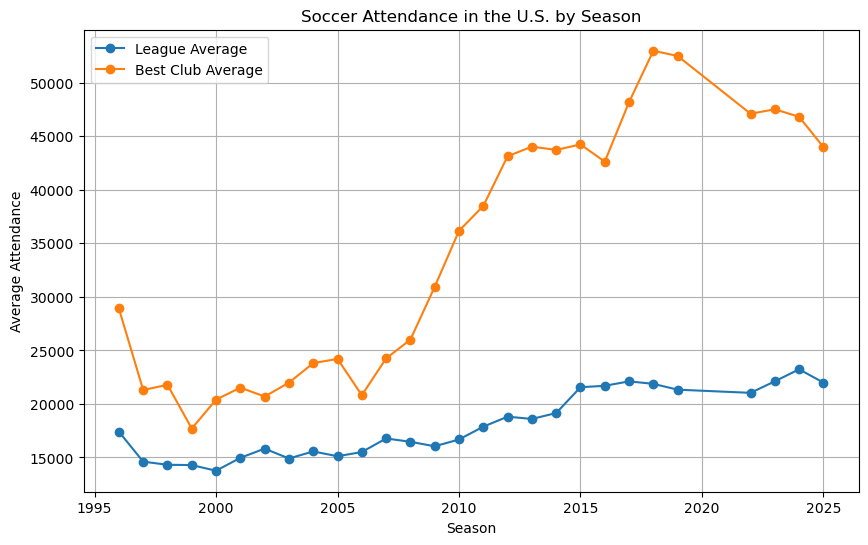

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(graph_df["Season"], graph_df["League average"], marker="o", label="League Average")
plt.plot(graph_df["Season"], graph_df["Best club average"], marker="o", label="Best Club Average")

plt.title("Soccer Attendance in the U.S. by Season")
plt.xlabel("Season")
plt.ylabel("Average Attendance")
plt.legend()
plt.grid(True)

plt.show()